In [81]:
from ultralytics import YOLO
import warnings
warnings.filterwarnings('ignore')
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import cv2

In [ ]:
def circle_from_segmentation(image, model):
    res = model(image)
    polygons = res[0].masks.xy
    
    if not polygons or all(len(p) == 0 for p in polygons):
        return None, None

    h, w = image.shape[:2]
    center = np.array([w / 2, h / 2])

    # One centroid per mask
    centroids = np.array([p.mean(axis=0) for p in polygons if len(p) > 0])
    dists = np.linalg.norm(centroids - center, axis=1)
    sorted_dists = np.sort(dists)[::-1]
    max_dist = sorted_dists[0]

    # If circle goes outside image, use IQR fallback
    max_possible = min(h, w) * 0.7
    if max_dist > max_possible and len(sorted_dists) > 10   :
        max_dist = np.percentile(sorted_dists, 75)

    # Padding if small
    min_half_dim = min(h, w) / 4
    if max_dist < min_half_dim:
        radius = max_dist * 1.15
    else:
        radius = max_dist

    cx, cy = int(round(center[0])), int(round(center[1]))
    radius = int(round(radius))

    return (cx, cy), radius


def apply_circle_mask(image, center, radius):
    """Black out everything outside the circle."""
    mask = np.zeros(image.shape[:2], dtype=np.uint8)
    cv2.circle(mask, center, radius, 255, thickness=-1)  # filled circle
    masked = image.copy()
    masked[mask == 0] = 0
    return masked

def show_images_with_circles(dir, model, n=5, reversed=False):
    images = [f for f in os.listdir(dir)
                 if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    images = sorted(images)
    for i in range(n):
        img_path = os.path.join(dir, images[i])
        img = cv2.imread(img_path)
        if reversed:
            img = img.max() - img
        
        center, radius = circle_from_segmentation(img, model)
        
        if center is not None and radius is not None:
            # Draw circle outline for visualization
            img_with_circle = img.copy()
            cv2.circle(img_with_circle, center, radius, (0, 255, 0), 2)
            
            # Apply the circular mask
            clipped = apply_circle_mask(img, center, radius)
        else:
            img_with_circle = img
            clipped = img

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(cv2.cvtColor(img_with_circle, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f'Circle overlay\n{img_path}')
        axes[0].axis('off')
        
        axes[1].imshow(cv2.cvtColor(clipped, cv2.COLOR_BGR2RGB))
        axes[1].set_title('Clipped (black outside circle)')
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()

In [83]:
input_dir = "./data/black_larva/frames/"


In [84]:
model = YOLO("/Users/caglayantuna/larva_codes/my_codes/yolo_runs_with_bordeaux_and_reversed_and_rotated/segment/train/weights/best.pt")



0: 864x1056 27 larvas, 4512.3ms
Speed: 19.5ms preprocess, 4512.3ms inference, 318.5ms postprocess per image at shape (1, 3, 864, 1056)


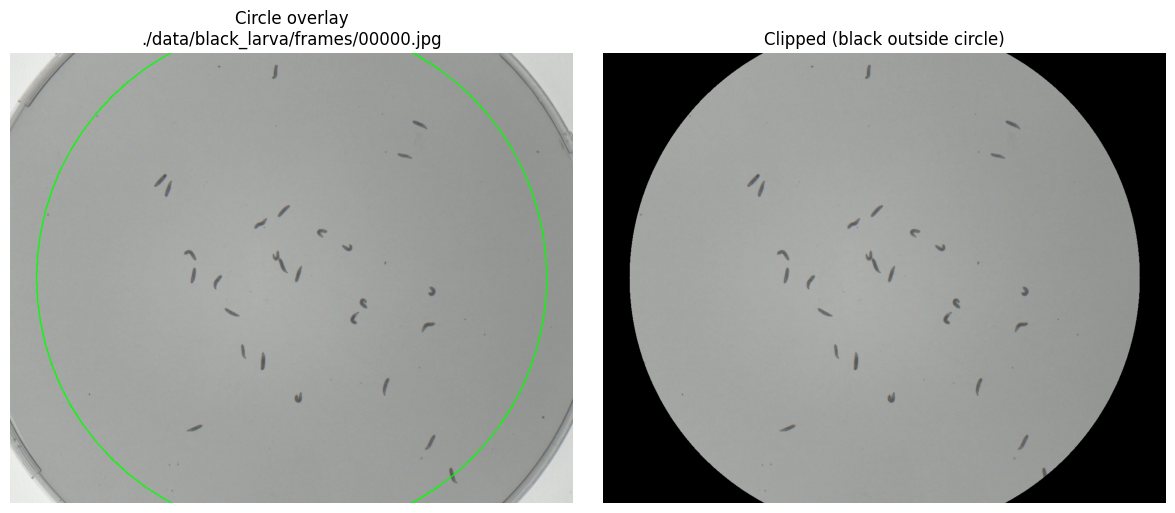


0: 864x1056 27 larvas, 3507.4ms
Speed: 26.6ms preprocess, 3507.4ms inference, 133.5ms postprocess per image at shape (1, 3, 864, 1056)


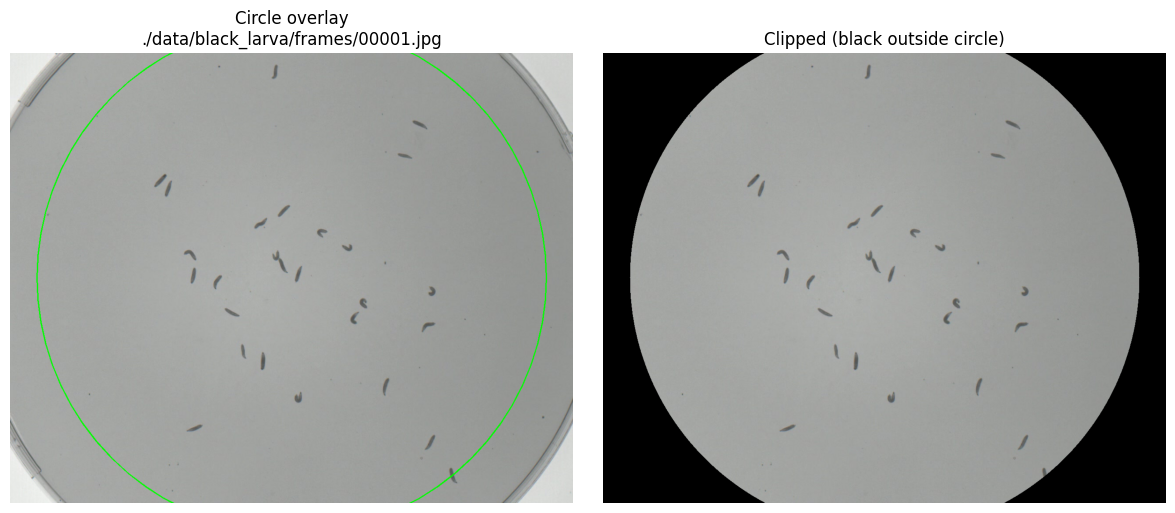


0: 864x1056 28 larvas, 3499.0ms
Speed: 47.1ms preprocess, 3499.0ms inference, 135.5ms postprocess per image at shape (1, 3, 864, 1056)


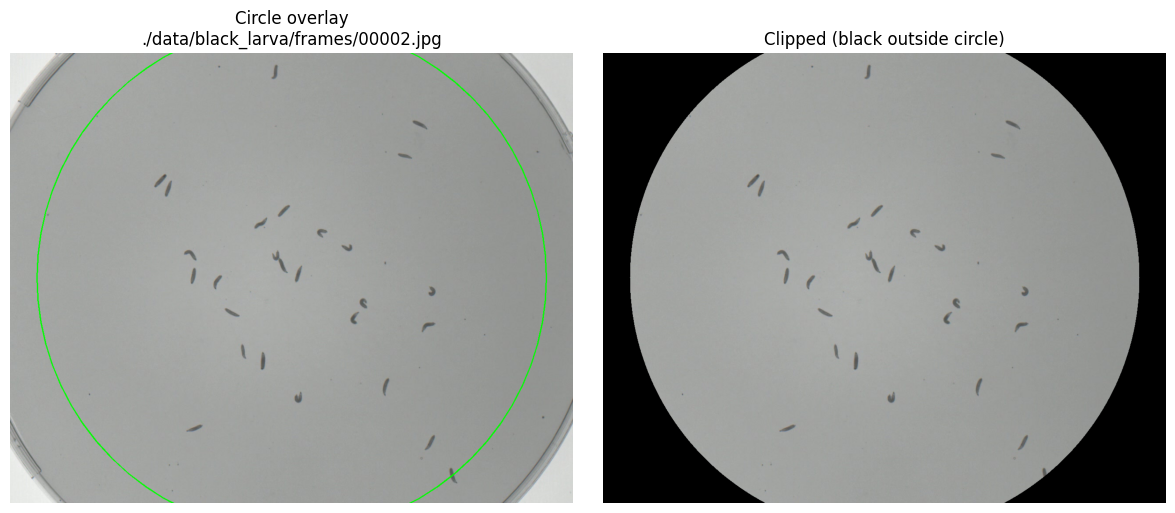


0: 864x1056 27 larvas, 3578.3ms
Speed: 49.2ms preprocess, 3578.3ms inference, 189.1ms postprocess per image at shape (1, 3, 864, 1056)


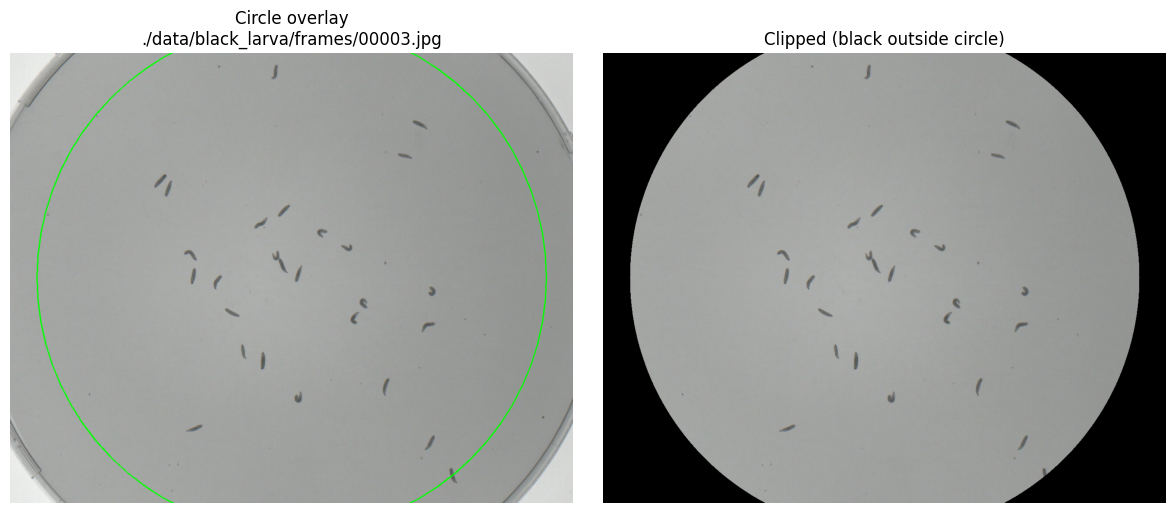


0: 864x1056 27 larvas, 3535.9ms
Speed: 45.6ms preprocess, 3535.9ms inference, 138.8ms postprocess per image at shape (1, 3, 864, 1056)


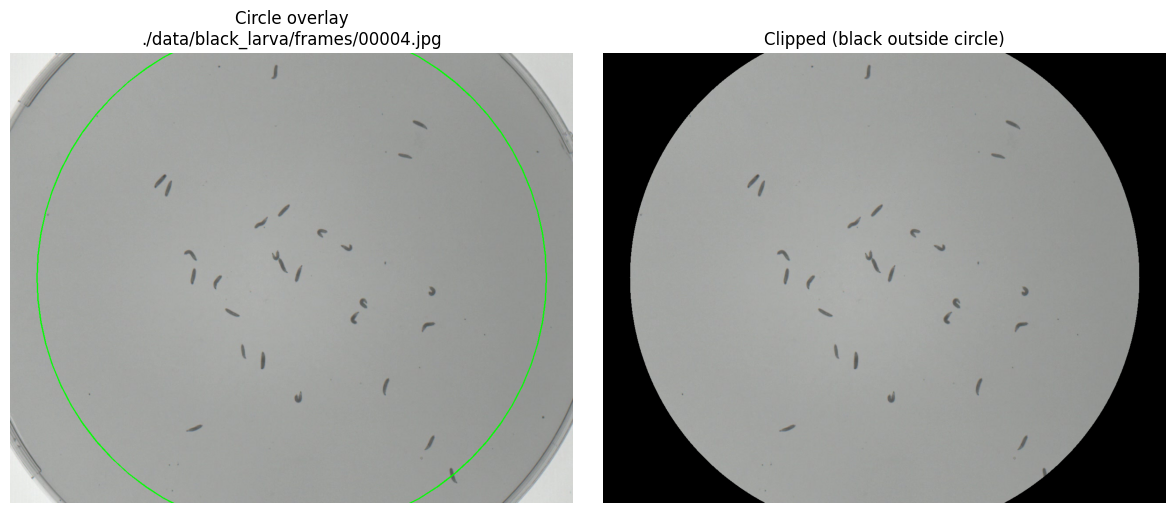

In [85]:
show_images_with_circles(input_dir, model, n=5)


0: 704x1056 80 larvas, 2911.7ms
Speed: 11.8ms preprocess, 2911.7ms inference, 816.8ms postprocess per image at shape (1, 3, 704, 1056)


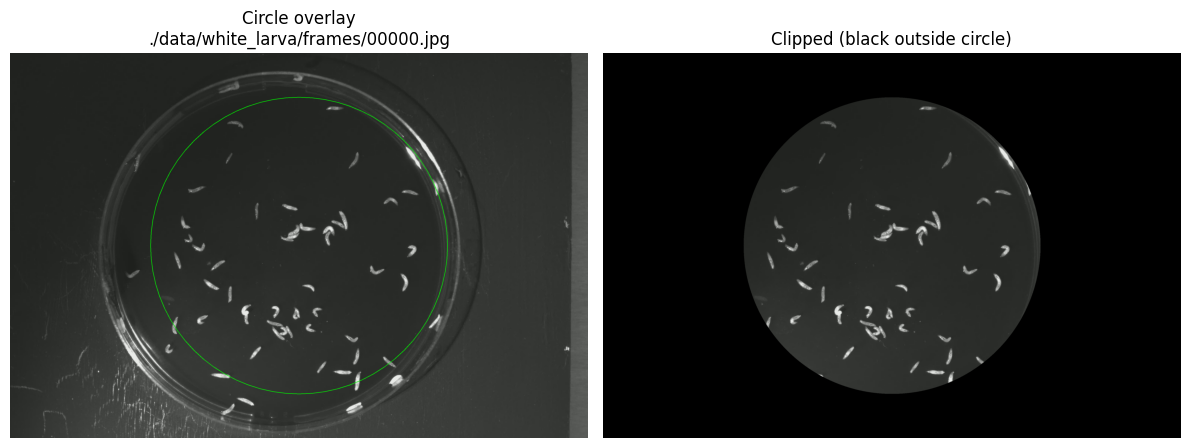


0: 704x1056 81 larvas, 2720.6ms
Speed: 11.4ms preprocess, 2720.6ms inference, 499.7ms postprocess per image at shape (1, 3, 704, 1056)


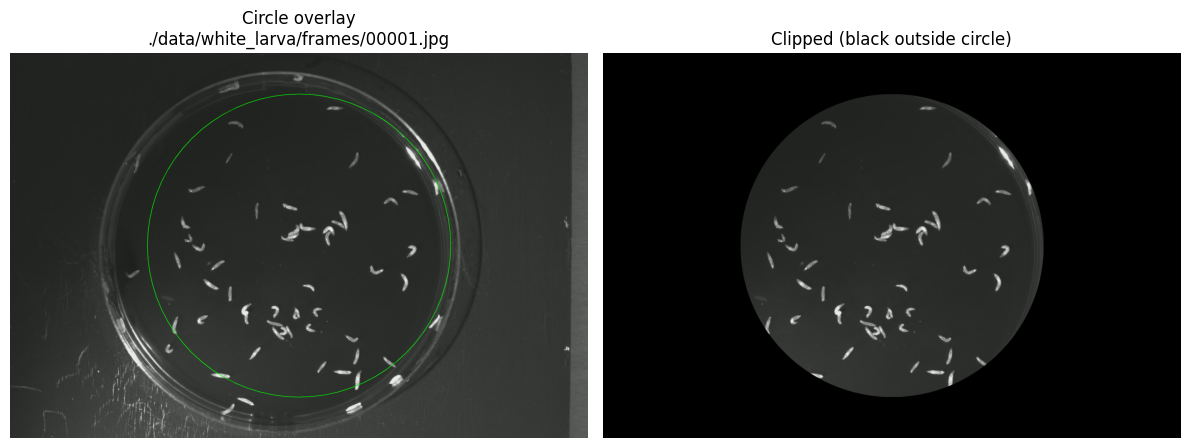


0: 704x1056 80 larvas, 2884.1ms
Speed: 17.4ms preprocess, 2884.1ms inference, 497.7ms postprocess per image at shape (1, 3, 704, 1056)


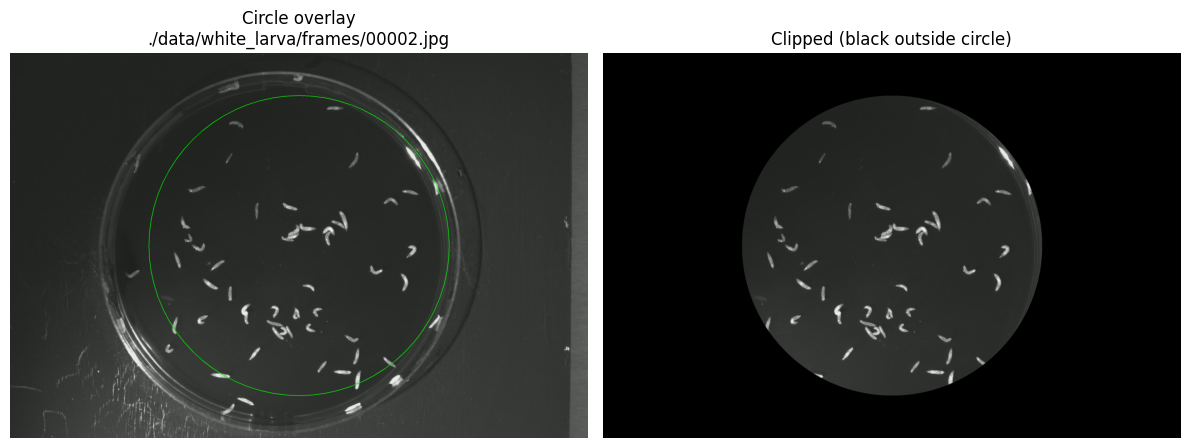


0: 704x1056 78 larvas, 2731.6ms
Speed: 32.1ms preprocess, 2731.6ms inference, 603.9ms postprocess per image at shape (1, 3, 704, 1056)


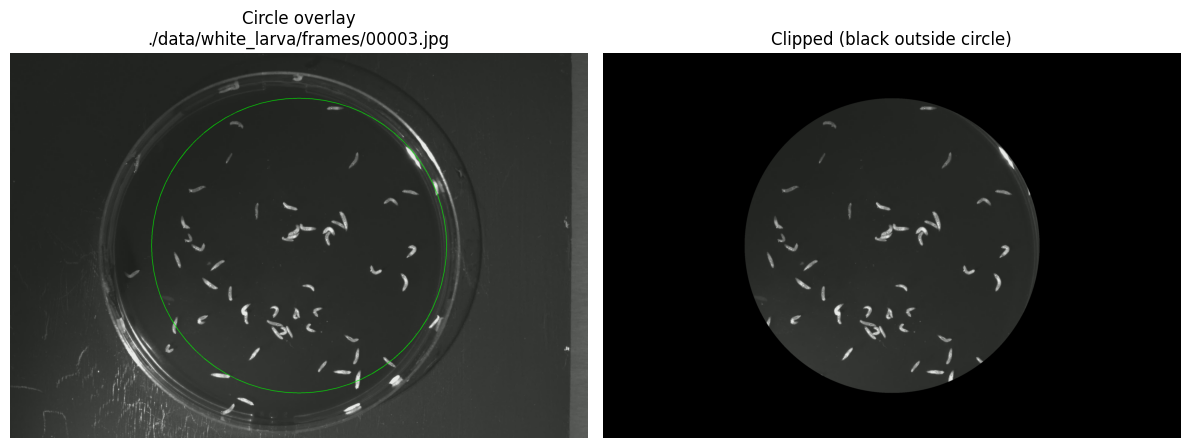


0: 704x1056 82 larvas, 2545.5ms
Speed: 36.0ms preprocess, 2545.5ms inference, 596.2ms postprocess per image at shape (1, 3, 704, 1056)


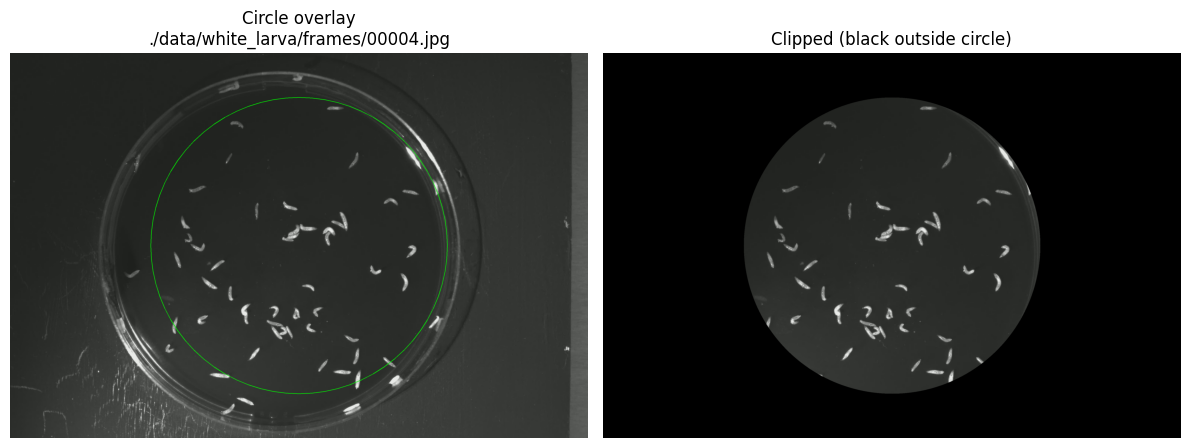

In [86]:

input_dir = "./data/white_larva/frames/"
show_images_with_circles(input_dir, model, n=5)